<a href="https://colab.research.google.com/github/DarkLyng/Challenge-TelecomX/blob/main/TelecomX_LATAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#📌 Extracción

In [273]:
#Bibliotecas

import requests
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [274]:
import warnings
warnings.filterwarnings('ignore')

In [275]:
#Enlace
enlace = "https://github.com/ingridcristh/challenge2-data-science-LATAM/blob/main/TelecomX_Data.json" #No funciona
enlace_raw = "https://raw.githubusercontent.com/alura-cursos/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json"

In [276]:
#Cargando los datos de Telecom X
r = requests.get(enlace_raw)
data = r.json()
df = pd.DataFrame(data)
df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


#🔧 Transformación

In [277]:
#Obteniendo información de los datos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


In [278]:
#Normalizando el archivo TelecomX_Data.json
df_normalizado = pd.json_normalize(data)
df_normalizado.sample(10)

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
172,0269-XFESX,No,Male,0,Yes,Yes,23,Yes,Yes,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,24.35,538.5
1123,1587-FKLZB,Yes,Male,1,Yes,Yes,66,Yes,Yes,Fiber optic,...,No,Yes,No,Yes,Yes,Month-to-month,Yes,Credit card (automatic),99.50,6822.15
7197,9898-KZQDZ,Yes,Female,1,Yes,Yes,40,Yes,Yes,Fiber optic,...,No,No,No,Yes,Yes,Month-to-month,Yes,Credit card (automatic),94.55,3640.45
6251,8605-ITULD,No,Female,0,No,No,1,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,19.55,19.55
4759,6518-LGAOV,Yes,Female,0,Yes,No,38,Yes,Yes,Fiber optic,...,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,105.00,4026.4
6143,8404-GFGCZ,No,Male,0,Yes,No,4,Yes,Yes,DSL,...,No,Yes,No,Yes,No,Month-to-month,No,Electronic check,65.60,250.1
5477,7508-DQAKK,No,Female,0,No,No,64,Yes,Yes,DSL,...,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),86.40,5442.05
97,0156-FVPTA,Yes,Male,0,Yes,No,22,Yes,No,DSL,...,No,No,Yes,No,No,Month-to-month,Yes,Electronic check,54.20,1152.7
6242,8591-NXRCV,No,Female,0,No,No,41,Yes,Yes,DSL,...,No,Yes,Yes,No,Yes,Month-to-month,Yes,Bank transfer (automatic),74.65,3090.65
6673,9172-JITSM,Yes,Female,0,Yes,Yes,26,Yes,No,Fiber optic,...,No,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,90.80,2361.8


In [279]:
#Información de los datos normalizados
df_normalizado.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

In [280]:
#Comprobación datos nulos
df_normalizado.isnull().sum().rename("Datos Nulos")

,Datos Nulos
customerID,0
Churn,0
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0


In [281]:
#Comprobación de datos duplicados
df_normalizado.duplicated().sum()

np.int64(0)

In [282]:
#Comprobación de strings vacíos o con espacios en el DataFrame
for col in df_normalizado.select_dtypes(include='object').columns:
    espacios = df_normalizado[col].str.isspace().sum()
    vacios = (df_normalizado[col] == "").sum()
    if espacios > 0 or vacios > 0:
        print(f"Columna '{col}': {espacios} celdas con espacios y {vacios} celdas vacías.")

Columna 'Churn': 0 celdas con espacios y 224 celdas vacías.
Columna 'account.Charges.Total': 11 celdas con espacios y 0 celdas vacías.


In [283]:
#Se observa que tiene valores que son espacio vacíos
df_normalizado["Churn"].unique()

array(['No', 'Yes', ''], dtype=object)

In [284]:
#Se eliminan los espacios vacíos
df_normalizado = df_normalizado.query("Churn != '' ")


In [285]:
# Buscar valores no numéricos en account.Charges.Total
df_normalizado[~df_normalizado['account.Charges.Total'].astype(str).str.contains(r'^-?\d*\.?\d+$')].head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
975,1371-DWPAZ,No,Female,0,Yes,Yes,0,No,No phone service,DSL,...,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,
1775,2520-SGTTA,No,Female,0,Yes,Yes,0,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,
1955,2775-SEFEE,No,Male,0,No,Yes,0,Yes,Yes,DSL,...,Yes,No,Yes,No,No,Two year,Yes,Bank transfer (automatic),61.90,
2075,2923-ARZLG,No,Male,0,Yes,Yes,0,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,
2232,3115-CZMZD,No,Male,0,No,Yes,0,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,


In [286]:
#Eliminar estos espacios
df_normalizado=df_normalizado[df_normalizado['account.Charges.Total'].astype(str).str.contains(r'^-?\d*\.?\d+$')]

In [287]:
#Reemplazar "No phone service" y "No internet service" en "No"
df_normalizado.replace("No phone service", "No", inplace=True)
df_normalizado.replace("No internet service", "No", inplace=True)
df_normalizado.replace("No", 0, inplace=True)
df_normalizado.replace("Yes", 1, inplace=True)

In [288]:
# Convertir la columna account.Charges.Total a float
df_normalizado['account.Charges.Total'] = pd.to_numeric(df_normalizado['account.Charges.Total'], errors='coerce')

In [289]:
df_normalizado.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7032 non-null   object 
 1   Churn                      7032 non-null   int64  
 2   customer.gender            7032 non-null   object 
 3   customer.SeniorCitizen     7032 non-null   int64  
 4   customer.Partner           7032 non-null   int64  
 5   customer.Dependents        7032 non-null   int64  
 6   customer.tenure            7032 non-null   int64  
 7   phone.PhoneService         7032 non-null   int64  
 8   phone.MultipleLines        7032 non-null   int64  
 9   internet.InternetService   7032 non-null   object 
 10  internet.OnlineSecurity    7032 non-null   int64  
 11  internet.OnlineBackup      7032 non-null   int64  
 12  internet.DeviceProtection  7032 non-null   int64  
 13  internet.TechSupport       7032 non-null   int64  
 1

In [290]:
#Muestra de los datos ya corregidos
df_normalizado.sample(5)

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
4365,5986-WWXDV,0,Male,0,0,1,39,1,0,0,...,0,0,0,0,0,One year,0,Bank transfer (automatic),19.35,779.2
5910,8070-AAWZP,0,Male,1,1,0,24,0,0,DSL,...,0,1,1,0,0,Month-to-month,0,Mailed check,34.25,828.2
3278,4568-TTZRT,0,Male,0,0,0,9,1,0,0,...,0,0,0,0,0,Month-to-month,0,Mailed check,20.40,181.8
6146,8405-IGQFX,0,Female,0,0,0,63,1,0,Fiber optic,...,0,1,1,1,0,One year,1,Credit card (automatic),90.05,5817.0
3335,4636-TVXVG,0,Male,0,1,1,62,1,0,0,...,0,0,0,0,0,One year,0,Bank transfer (automatic),19.95,1244.8


In [291]:

df_normalizado.to_csv("df_normalizado.csv", index=False)

#📊 Carga y análisis

In [292]:
#Análisis descriptivo

df_describe = df_normalizado.describe().T

estilo = df_describe.style
estilo.format({"count": "{:.0f}",
                           "mean": "{:.2%}",
                           "std": "{:.2%}",
                           "25%": "{:.2%}",
                           "50%": "{:.2%}",
                           "75%": "{:.2%}",
                           "max": "{:.2f}",
                           "min": "{:.2f}"
                        })

,count,mean,std,min,25%,50%,75%,max
Churn,7032,26.58%,44.18%,0.00,0.00%,0.00%,100.00%,1.00
customer.SeniorCitizen,7032,16.24%,36.88%,0.00,0.00%,0.00%,0.00%,1.00
customer.Partner,7032,48.25%,49.97%,0.00,0.00%,0.00%,100.00%,1.00
customer.Dependents,7032,29.85%,45.76%,0.00,0.00%,0.00%,100.00%,1.00
customer.tenure,7032,3242.18%,2454.53%,1.00,900.00%,2900.00%,5500.00%,72.00
phone.PhoneService,7032,90.33%,29.56%,0.00,100.00%,100.00%,100.00%,1.00
phone.MultipleLines,7032,42.19%,49.39%,0.00,0.00%,0.00%,100.00%,1.00
internet.OnlineSecurity,7032,28.65%,45.22%,0.00,0.00%,0.00%,100.00%,1.00
internet.OnlineBackup,7032,34.49%,47.54%,0.00,0.00%,0.00%,100.00%,1.00
internet.DeviceProtection,7032,34.39%,47.50%,0.00,0.00%,0.00%,100.00%,1.00


In [293]:
#Gráfica de distribución de evasión
df_evasion=df_normalizado['Churn'].value_counts(normalize=True).rename(index={1:"Si",0:"No"})*100
df_evasion

,proportion
Churn,
No,73.421502
Si,26.578498


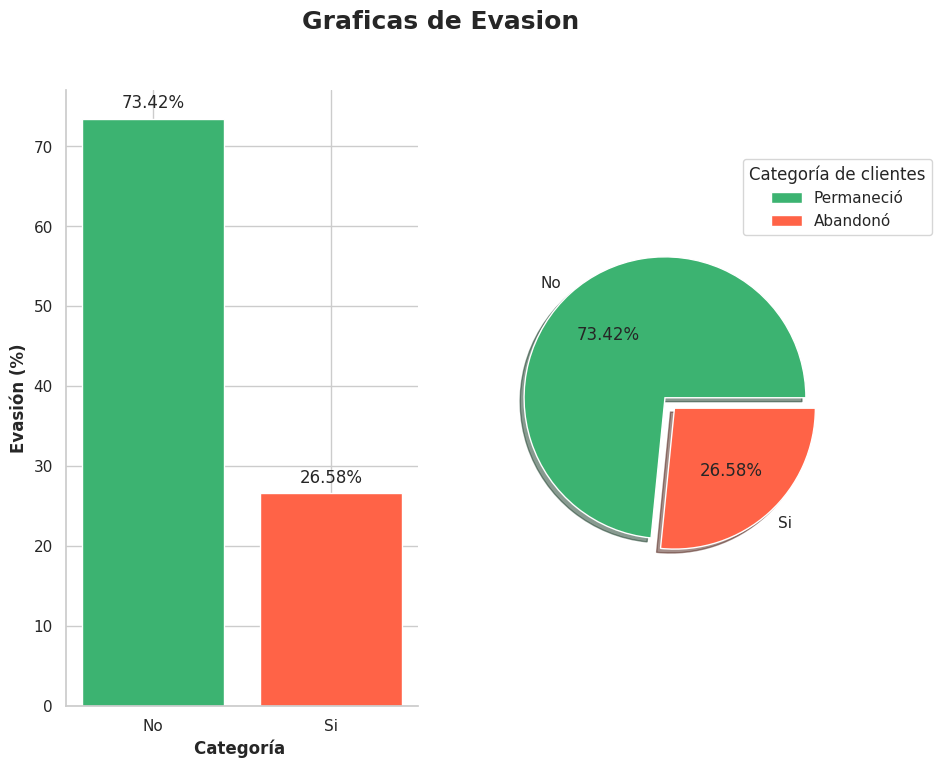

In [294]:
color = ['mediumseagreen', 'tomato']
leyendas = ["Permaneció", "Abandonó"]
desfase = (0, 0.1)

def graf_evasion():
    fig, axs =plt.subplots(1,2, figsize=(10,8))
    fig.suptitle("Graficas de Evasion", fontsize=18, fontweight="bold")

    #Gráfica de barras
    axs[0].bar(df_evasion.index, df_evasion.values, color=color)
    axs[0].set_ylabel("Evasión (%)", fontsize=12, fontweight="bold")
    axs[0].set_xlabel("Categoría ", fontsize=12, fontweight="bold")
    axs[0].spines['top'].set_visible(False)
    axs[0].spines['right'].set_visible(False)
    for i, j in enumerate(df_evasion.values):
        axs[0].text(i,j+2,str(j.round(2))+"%",ha="center",va="center")

    #Gráfica de pie
    axs[1].pie(df_evasion, labels=df_evasion.index, colors=color, autopct="%1.2f%%", explode=desfase, shadow=True)
    axs[1].legend(title="Categoría de clientes", loc="upper left", bbox_to_anchor=(0.7, 1.2), labels=leyendas)
    return plt

graf_evasion().show()

In [295]:
df_normalizado.head(1)

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,0,Female,0,1,1,9,1,0,DSL,...,1,0,1,1,0,One year,1,Mailed check,65.6,593.3


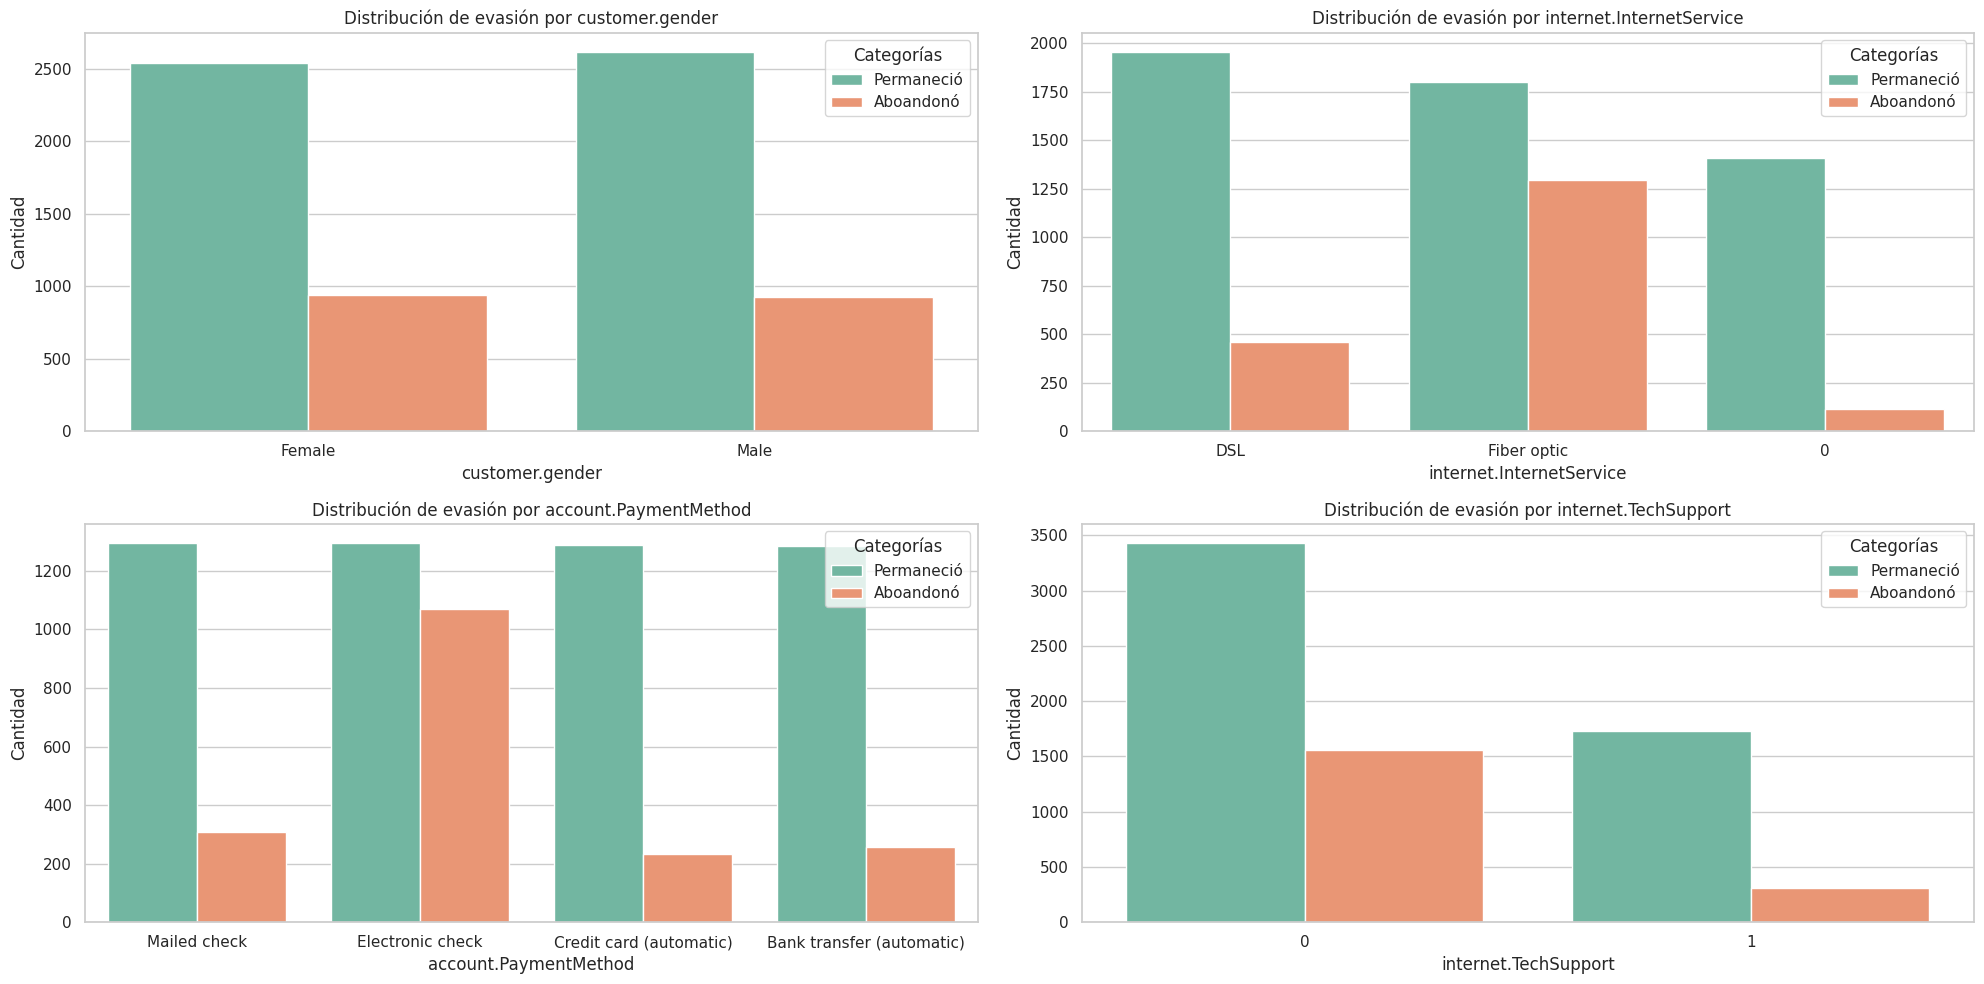

In [296]:
# Seleccionamos las 4 variables con mayor impacto en el negocio
columnas = [
    'customer.gender',            # Género
    'internet.InternetService',   # Tipo de contrato
    'account.PaymentMethod',      # Método de pago
    'internet.TechSupport'        # Soporte_Tecnico
]
def graf_evasion_columnas():

  fig, axes = plt.subplots(2,2, figsize=(20,10))
  axes = axes.flatten()

  for col, ax in zip(columnas, axes):
    sns.countplot(data=df_normalizado, hue="Churn", x=col, ax=ax, palette="Set2")
    ax.set_title(f'Distribución de evasión por {col}')
    ax.set_ylabel('Cantidad')
    ax.legend(title= 'Categorías', labels= ["Permaneció", "Aboandonó"])

  plt.tight_layout()
  return plt

graf_evasion_columnas().show()

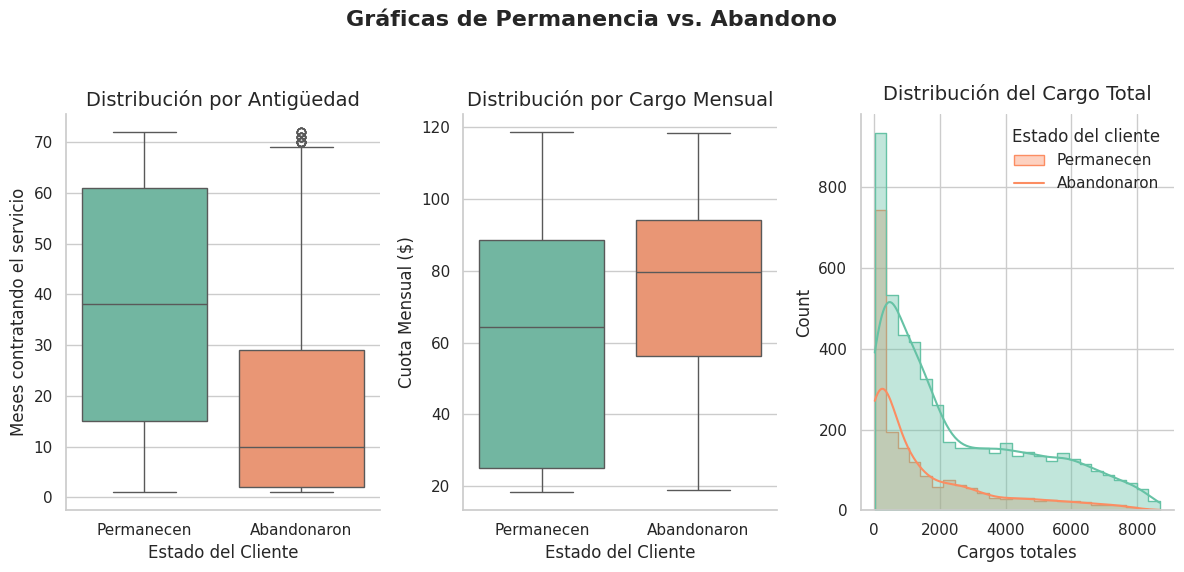

In [297]:
#Gráfica conteo de evasión por variables numéricas

def graf_evasion_numericas():

  sns.set_theme(style="whitegrid")

  fig, ax = plt.subplots(1, 3, figsize=(12, 6))
  fig.suptitle('Gráficas de Permanencia vs. Abandono', fontsize=16, fontweight='bold')

# Antigüedad
  sns.boxplot(data=df_normalizado, x='Churn', y='customer.tenure',
              palette='Set2', ax=ax[0], hue='Churn', legend=False)
  ax[0].set_title('Distribución por Antigüedad', fontsize=14)
  ax[0].set_xlabel('Estado del Cliente', fontsize=12)
  ax[0].set_ylabel('Meses contratando el servicio', fontsize=12)
  ax[0].set_xticklabels(['Permanecen', 'Abandonaron'])

# Cargo Mensual
  sns.boxplot(data=df_normalizado, x='Churn', y='account.Charges.Monthly',
              palette='Set2', ax=ax[1], hue='Churn', legend=False)
  ax[1].set_title('Distribución por Cargo Mensual', fontsize=14)
  ax[1].set_xlabel('Estado del Cliente', fontsize=12)
  ax[1].set_ylabel('Cuota Mensual ($)', fontsize=12)
  ax[1].set_xticklabels(['Permanecen', 'Abandonaron'])

# Cargo Total
  sns.histplot(data=df_normalizado, x='account.Charges.Total', hue='Churn',
               kde=True, element="step", palette='Set2', ax=ax[2], alpha=0.4)
  ax[2].set_title('Distribución del Cargo Total', fontsize=14, pad=10)
  ax[2].legend(title='Estado del cliente', labels=['Permanecen', 'Abandonaron'], frameon=False)
  ax[2].set_xlabel('Cargos totales', fontsize=12)


  sns.despine()
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])
  return plt

graf_evasion_numericas().show()



#📄Informe final

**🔹 Introducción**

El objetivo principal de este proyecto es descifrar los patrones de comportamiento de los clientes para identificar las causas del aumento en la tasa de deserción en la plataforma Telecom X. Mediante el uso de Python y Pandas, realizaremos un análisis estadístico, con el fin de convertir los datos crudos en conjuntos de datos más claros y visuluzaciones que permitirán mejorar las futuras decisiones de la empresa.


**🔹 Proceso ETL**

**Preparando los datos para el análisis**

Antes de empezar, tuvimos que preparar los datos, el cual fue proceso limpieza y organización, ya que la información venía anidada, por estar en formato JSON. Así fue como lo logramos:

Tomamos archivos que estaban anidados y los convertimos en un conjunto de datos más claro, estos se dividieron y pasaron de ser solo 6 categorías a 21 columnas las cuales corresponden a características que nos servirán para entender mejor a cada cliente.

Luego se procedió a quitar los datos que estaban incompletos y duplicados, es decir, si a un registro le faltaba un dato necesario para el estudio o si el cliente se había ido, se excluía del análisis, lo que nos dejó con una lista de 7,032 clientes.


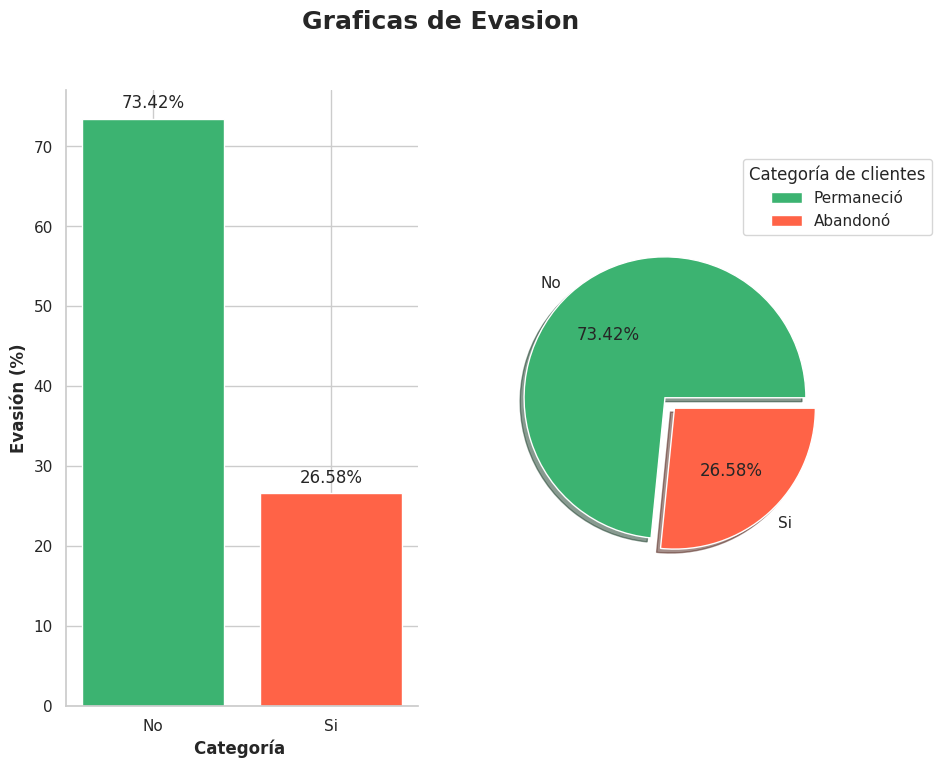

In [298]:
graf_evasion().show()

**Análisis de DataFrame**

Se observó que de cada 100 clientes, aproximadamente 73 permanecen conntratando el servicio de la empresa mientras que 27 deciden irse. Al investigar por qué se van, encontramos estos puntos clave:

*   Los clientes que pagan cada mes son los que más rápido abandonan el servicio, en cambio, los que firman por un año o más son mucho más leales (9 de cada 10 se quedan).

*    Las personas que pagan con "Cheque Electrónico" se van mucho más que las que tienen el pago automático con tarjeta de crédito, se puede decir que hacer el proceso manual cada mes desmotiva al cliente a tener que salir para realizarlo.

*    Se observa que los clientes de Fibra Óptica (que es el servicio más caro) se van más seguido que los de internet básico (DSL), esto podría ser porque el precio del servicio de fibra óptica es muy alto en comparación con el de otras compañias.

*    La mayoría de los clientes que abandonan la empresa lo hacen durante su primer año, luego de los 12 meses es muy probable que se quede por mucho más tiempo.

*    Al comparar los grupos con las gráficas de cajas (Boxplots), se observa que en promedio, los clientes que se van, presentaban facturas más altas que los que deciden quedarse.

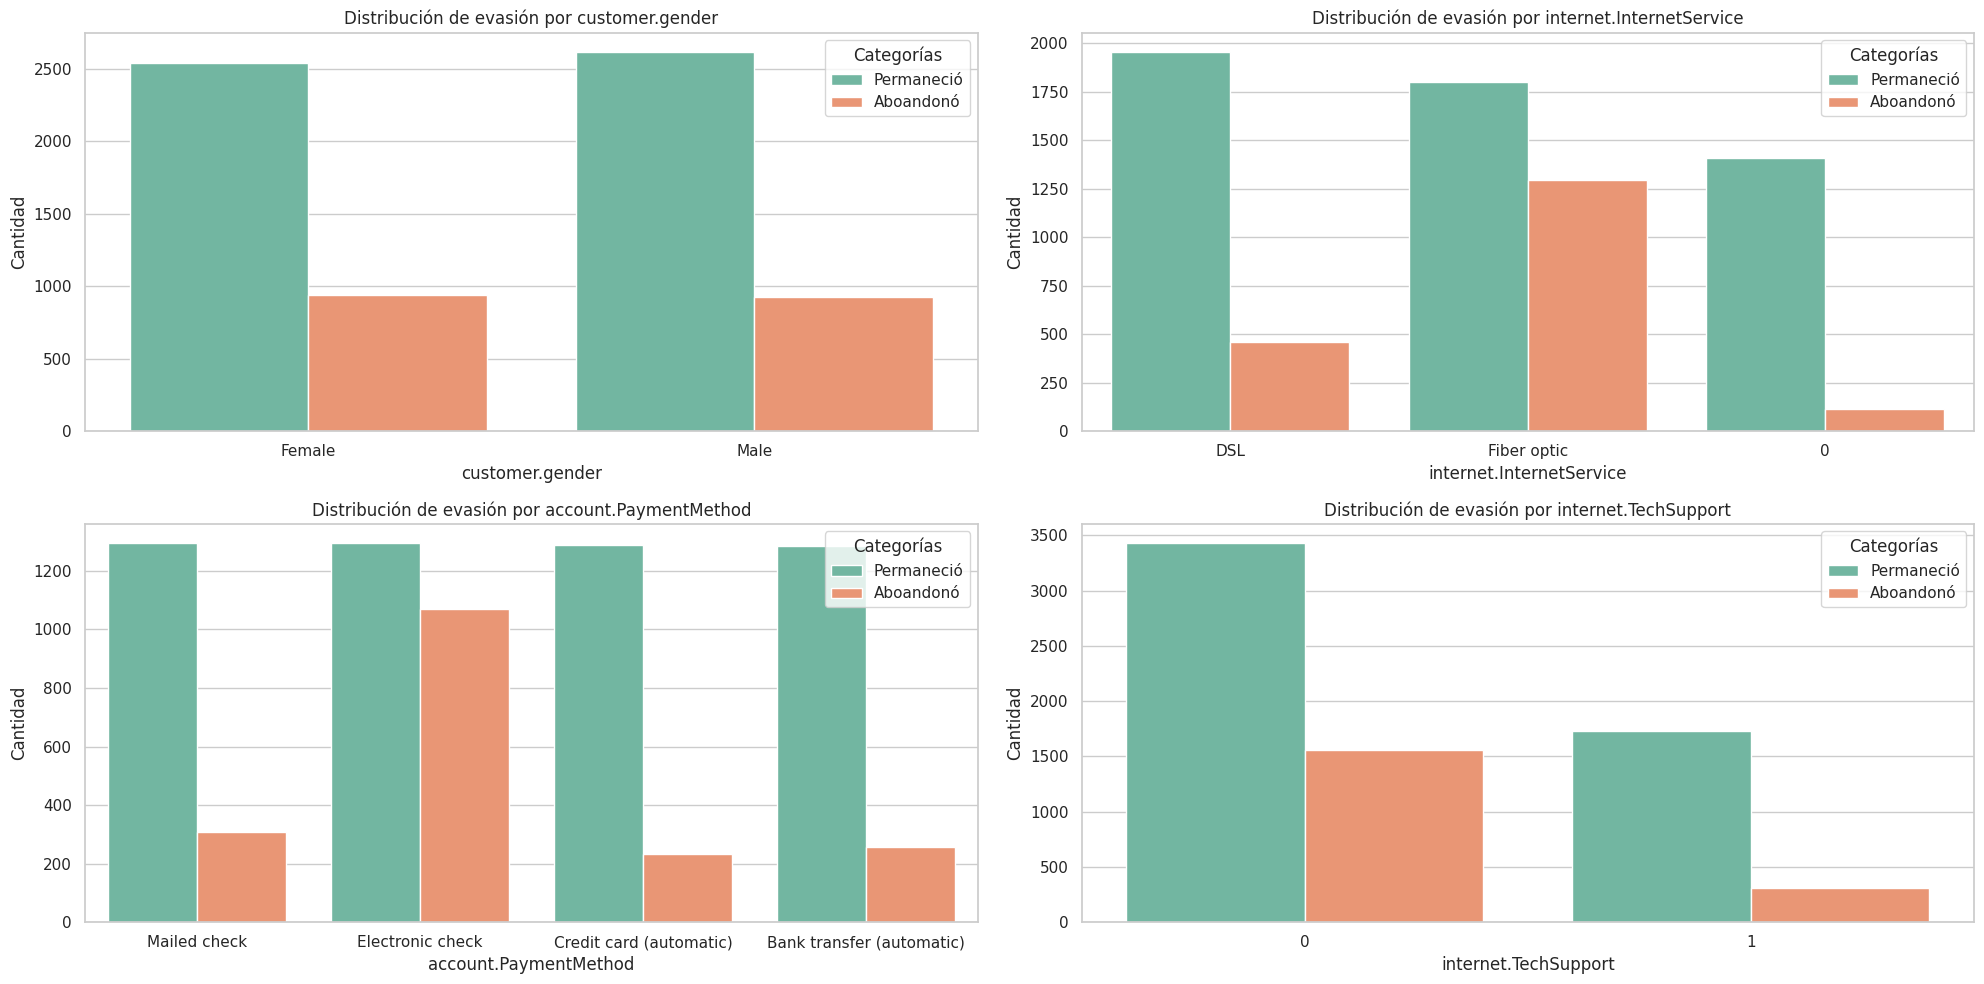

In [299]:
graf_evasion_columnas().show()

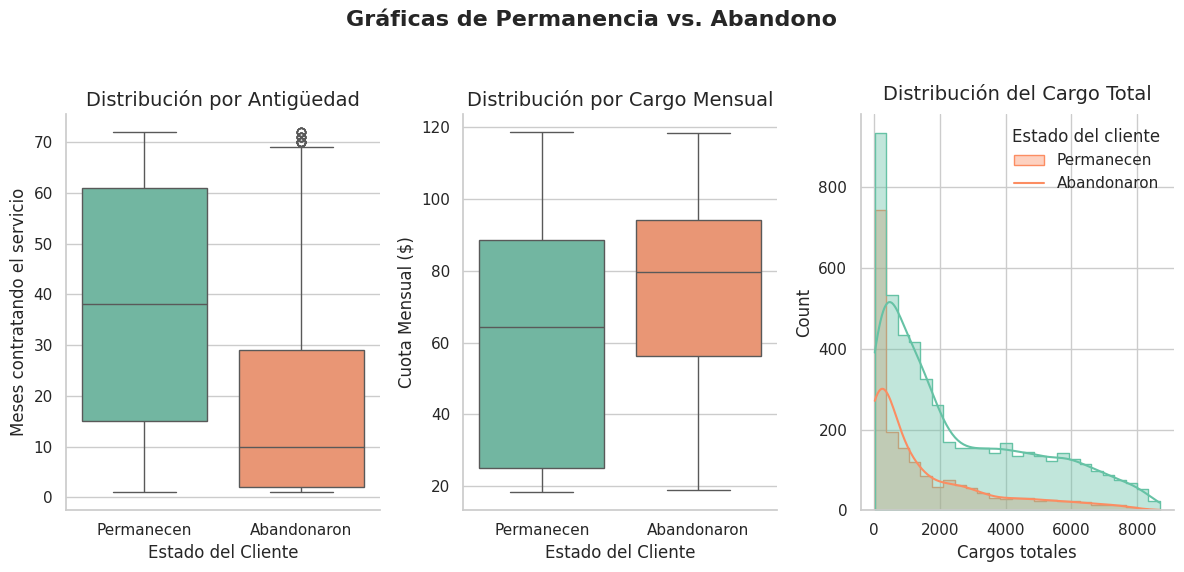

In [300]:
graf_evasion_numericas().show()

**🔹 Conclusiones:**
*  Los clientes que pagan mes a mes abandonan el servicio más facilmente(casi la mitad) que los que firman por uno o dos años, estos suelen quedarse.

*  Se observa que 4 de cada 10 clientes de Fibra Óptica abandonan el servicio, mientras que los que contratan el servicio DSL suelen permanecer por mucho más tiempo.

*  Se notó que casi la mitad de los que pagan con "Automatic Check" terminan cancelando el servicio, con respecto a los otros métodos de pago, este es el que presenta mayor porcentaje de abandono.


**🔹 Recomendaciones:**

*   **Convencer a los clientes de quedarse más tiempo:**
Debería de aplicarse algún descuento o beneficio si aceptan cambiar su contrato mensual por uno anual, así aseguramos que permanezcan mucho más tiempo.

*   **Revisar qué pasa con el internet de Fibra Óptica:**
Se debe investigar si la razón por la que las personas dejan este servicio, si es porque el precio es muy alto, el internet falla regularmente o si el servicio técnico es ineficiente, para poder arreglarlo lo más pronto posible.

* **Hacer que pagar sea más fácil y automático:**
Se debe incentivar a estos clientes que pagan con Automatic Check a que utilicen el pago automático con su tarjeta, ya que si el pago se hace solo, el cliente no tiene que pasar por el inconveniente de hacer el trámite cada mes y es menos probable que piense en cancelar el servicio.